Cats vs Dogs Classifier

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

In [2]:
#Load images and split automatically
data_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2, #80% train/20% validation
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [3]:
train_data = data_gen.flow_from_directory(
    r"C:\Users\srine\Downloads\Deep learning practice\kagglecatsanddogs_5340\PetImages",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 19999 images belonging to 2 classes.


In [4]:
val_data = data_gen.flow_from_directory(
    r"C:\Users\srine\Downloads\Deep learning practice\kagglecatsanddogs_5340\PetImages",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 4998 images belonging to 2 classes.


Build CNN model

In [5]:
model = Sequential([
    Conv2D(32,(3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

C:\Users\srine\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [22]:
history = model.fit(
    train_data,
    epochs=2,
    validation_data=val_data
)

Epoch 1/2
304/625 ━━━━━━━━━━━━━━━━━━━━ 5:35 1s/step - accuracy: 0.7803 - loss: 0.4629

C:\Users\srine\AppData\Roaming\Python\Python313\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 729s 1s/step - accuracy: 0.7903 - loss: 0.4430 - val_accuracy: 0.8071 - val_loss: 0.4182
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 1289s 2s/step - accuracy: 0.8107 - loss: 0.4116 - val_accuracy: 0.8231 - val_loss: 0.3906


Visualize Accuracy

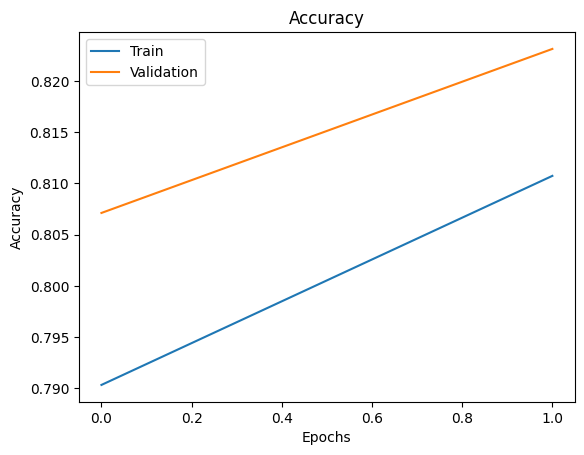

In [23]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

In [24]:
model.save("cats_dogs_model.h5")
print("Model saved successfully!")

Model saved successfully!


Predict a new image

In [25]:
from tensorflow.keras.preprocessing import image
import numpy as np

In [26]:
img = image.load_img(r"C:\Users\srine\Downloads\Deep learning practice\golden-retriever-dog-21668976.jpg", target_size=(150,150))
img_array= image.img_to_array(img) / 255
img_array= np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print('Prediction:', 'Dog' if prediction[0] > 0.5 else 'Cat')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Prediction: Dog


In [27]:
from ipywidgets import FileUpload
import io 
from PIL import Image
import numpy as np
from tensorflow.keras.preprocessing import image

In [28]:
uploader = FileUpload(accept='image/*', multiple=False)
uploader

FileUpload(value=(), accept='image/*', description='Upload')

In [29]:
def predict_uploaded(file):
    img =Image.open(io.BytesIO(file)).resize((150,150))
    img_array = image.img_to_array(img) / 255.0
    img_array= np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    result = "Dog" if prediction[0][0]>0.5 else "Cat"
    print("\nPrediction:", result)

In [30]:
if uploader.value:
    file_data=uploader.value[0]['content']
    predict_uploaded(file_data)

In [31]:
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image

In [32]:
model = load_model(r"C:\Users\srine\Downloads\Deep learning practice\cats_dogs_model.h5")

In [34]:
def predict(img):
    img = img.resize((150, 150))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    label = "Dog 🐶" if prediction[0][0] > 0.5 else "Cat 🐱"
    return label

interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="🐶🐱 Cat vs Dog Classifier",
    description="Upload a cat or dog image for prediction."
)

interface.launch(share=True)


* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://fcb39d24e4cef44161.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
